# Module 3 Project — Understanding Magazine Subscription Behavior
### Binary Classification using Logistic Regression & SVM
---

### PART 1 - Exploratory Data Analysis (EDA)

##### Import Libraries

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc

# display all columns
pd.set_option('display.max_columns', None)

print('All libraries loaded successfully.')

All libraries loaded successfully.


##### Load Data

In [47]:
df = pd.read_excel("marketing_campaign.xlsx")

##### Basic Data Understanding

In [48]:
# View first few rows
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [49]:
# Shape of dataset
df.shape

(2240, 29)

In [50]:
# Column names
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [51]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [52]:
# Statistical summary (numerical)
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [53]:
# Full summary including categorical
df.describe(include='all')

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240,2240,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
unique,NaN,NaN,5,8,NaN,NaN,NaN,663,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Graduation,Married,NaN,NaN,NaN,2012-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1127,864,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5592.159821,1968.805804,NaN,NaN,52247.251354,0.444196,0.506250,NaN,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,NaN,NaN,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,NaN,NaN,1730.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,NaN,NaN,35303.000000,0.000000,0.000000,NaN,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,NaN,NaN,51381.500000,0.000000,0.000000,NaN,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,NaN,NaN,68522.000000,1.000000,1.000000,NaN,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000


##### Missing Values Analysis

In [54]:
# Missing values per column
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

##### Duplicate Check

In [55]:
# Number of duplicate rows
print(df.duplicated().sum())

0


##### Target variable Distribution

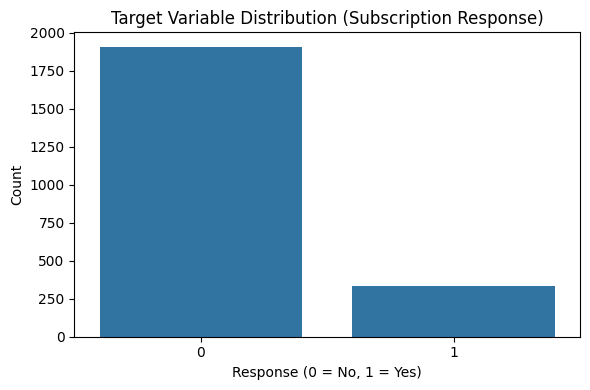

In [56]:
plt.figure(figsize=(6,4))
sns.countplot(x='Response', data=df)
plt.title("Target Variable Distribution (Subscription Response)")
plt.xlabel("Response (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

##### Numerical Feature Distributions

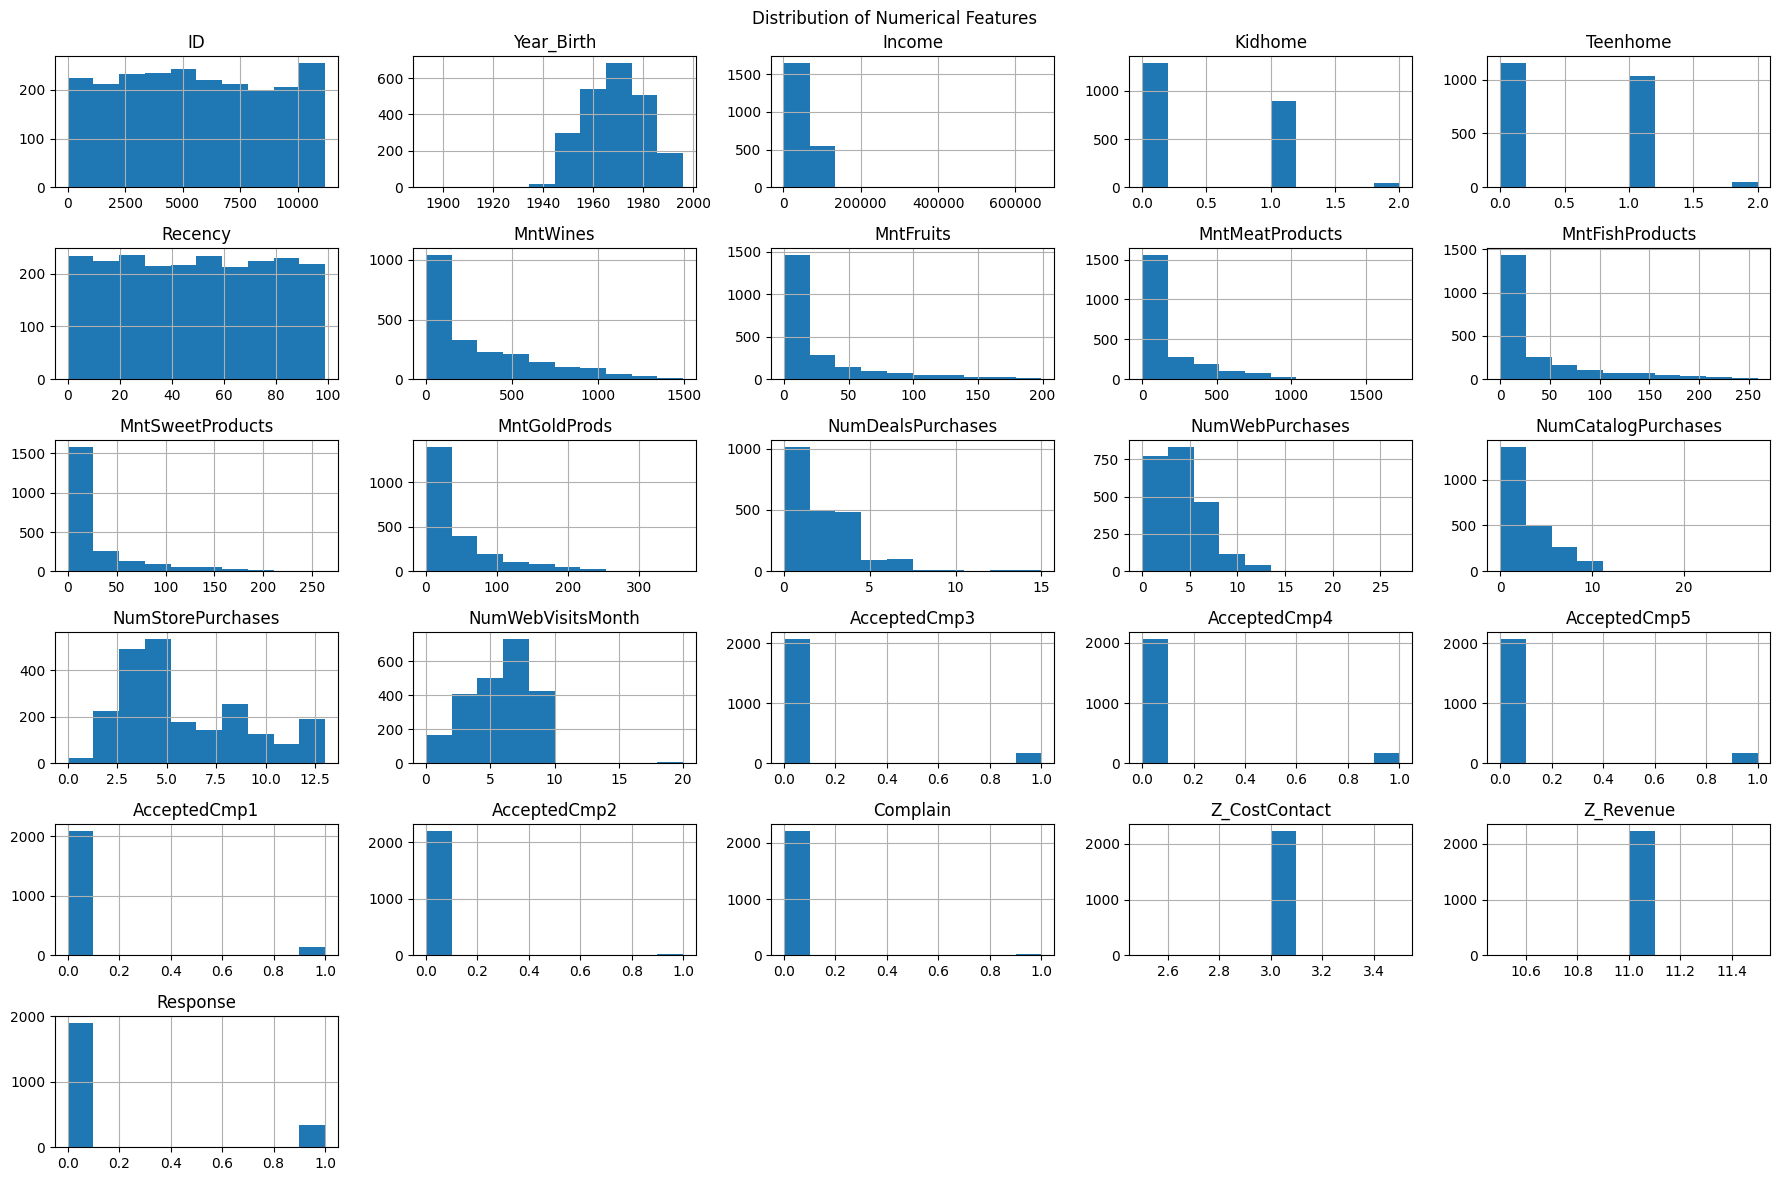

In [57]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].hist(figsize=(18,12))
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

##### Correlation Analysis

In [58]:
# Correlation matrix
corr = df.corr(numeric_only=True)
corr

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,1.000000,0.000028,0.013095,0.002406,-0.002580,-0.046524,-0.022878,0.004600,-0.004437,-0.024475,-0.007642,-0.013438,-0.037166,-0.018924,-0.003440,-0.014927,-0.007446,-0.036040,-0.025387,-0.007517,-0.021614,-0.015061,0.033883,NaN,NaN,-0.021968
Year_Birth,0.000028,1.000000,-0.161791,0.230176,-0.352111,-0.019871,-0.157773,-0.017917,-0.030872,-0.041625,-0.018133,-0.061818,-0.060846,-0.145040,-0.121275,-0.128272,0.121139,0.061774,-0.060510,0.007123,-0.005930,-0.006539,-0.030128,NaN,NaN,0.021325
Income,0.013095,-0.161791,1.000000,-0.428669,0.019133,-0.003970,0.578650,0.430842,0.584633,0.438871,0.440744,0.325916,-0.083101,0.387878,0.589162,0.529362,-0.553088,-0.016174,0.184400,0.335943,0.276820,0.087545,-0.027225,NaN,NaN,0.133047
Kidhome,0.002406,0.230176,-0.428669,1.000000,-0.036133,0.008827,-0.496297,-0.372581,-0.437129,-0.387644,-0.370673,-0.349595,0.221798,-0.361647,-0.502237,-0.499683,0.447846,0.014674,-0.161600,-0.205634,-0.172339,-0.081716,0.040207,NaN,NaN,-0.080008
Teenhome,-0.002580,-0.352111,0.019133,-0.036133,1.000000,0.016198,0.004846,-0.176764,-0.261160,-0.204187,-0.162475,-0.021725,0.387741,0.155500,-0.110769,0.050695,0.134884,-0.042677,0.038886,-0.191050,-0.140090,-0.015605,0.003138,NaN,NaN,-0.154446
Recency,-0.046524,-0.019871,-0.003970,0.008827,0.016198,1.000000,0.016064,-0.004306,0.023056,0.001079,0.022670,0.016693,-0.001098,-0.010726,0.025110,0.000799,-0.021445,-0.032991,0.018826,0.000129,-0.019283,-0.001781,0.013231,NaN,NaN,-0.198437
MntWines,-0.022878,-0.157773,0.578650,-0.496297,0.004846,0.016064,1.000000,0.389637,0.562667,0.399753,0.386581,0.387516,0.010940,0.542265,0.635226,0.642100,-0.320653,0.062202,0.373286,0.472613,0.354133,0.205907,-0.039007,NaN,NaN,0.247254
MntFruits,0.004600,-0.017917,0.430842,-0.372581,-0.176764,-0.004306,0.389637,1.000000,0.543105,0.594804,0.567164,0.392995,-0.132114,0.296735,0.487917,0.461758,-0.418383,0.014727,0.010152,0.215833,0.194748,-0.009773,-0.005166,NaN,NaN,0.125289
MntMeatProducts,-0.004437,-0.030872,0.584633,-0.437129,-0.261160,0.023056,0.562667,0.543105,1.000000,0.568402,0.523846,0.350609,-0.122415,0.293761,0.723827,0.479659,-0.539470,0.018272,0.102912,0.373769,0.309761,0.043033,-0.023483,NaN,NaN,0.236335
MntFishProducts,-0.024475,-0.041625,0.438871,-0.387644,-0.204187,0.001079,0.399753,0.594804,0.568402,1.000000,0.579870,0.422875,-0.139361,0.293681,0.534478,0.459855,-0.446003,0.000357,0.016843,0.199578,0.260762,0.002577,-0.020953,NaN,NaN,0.111331


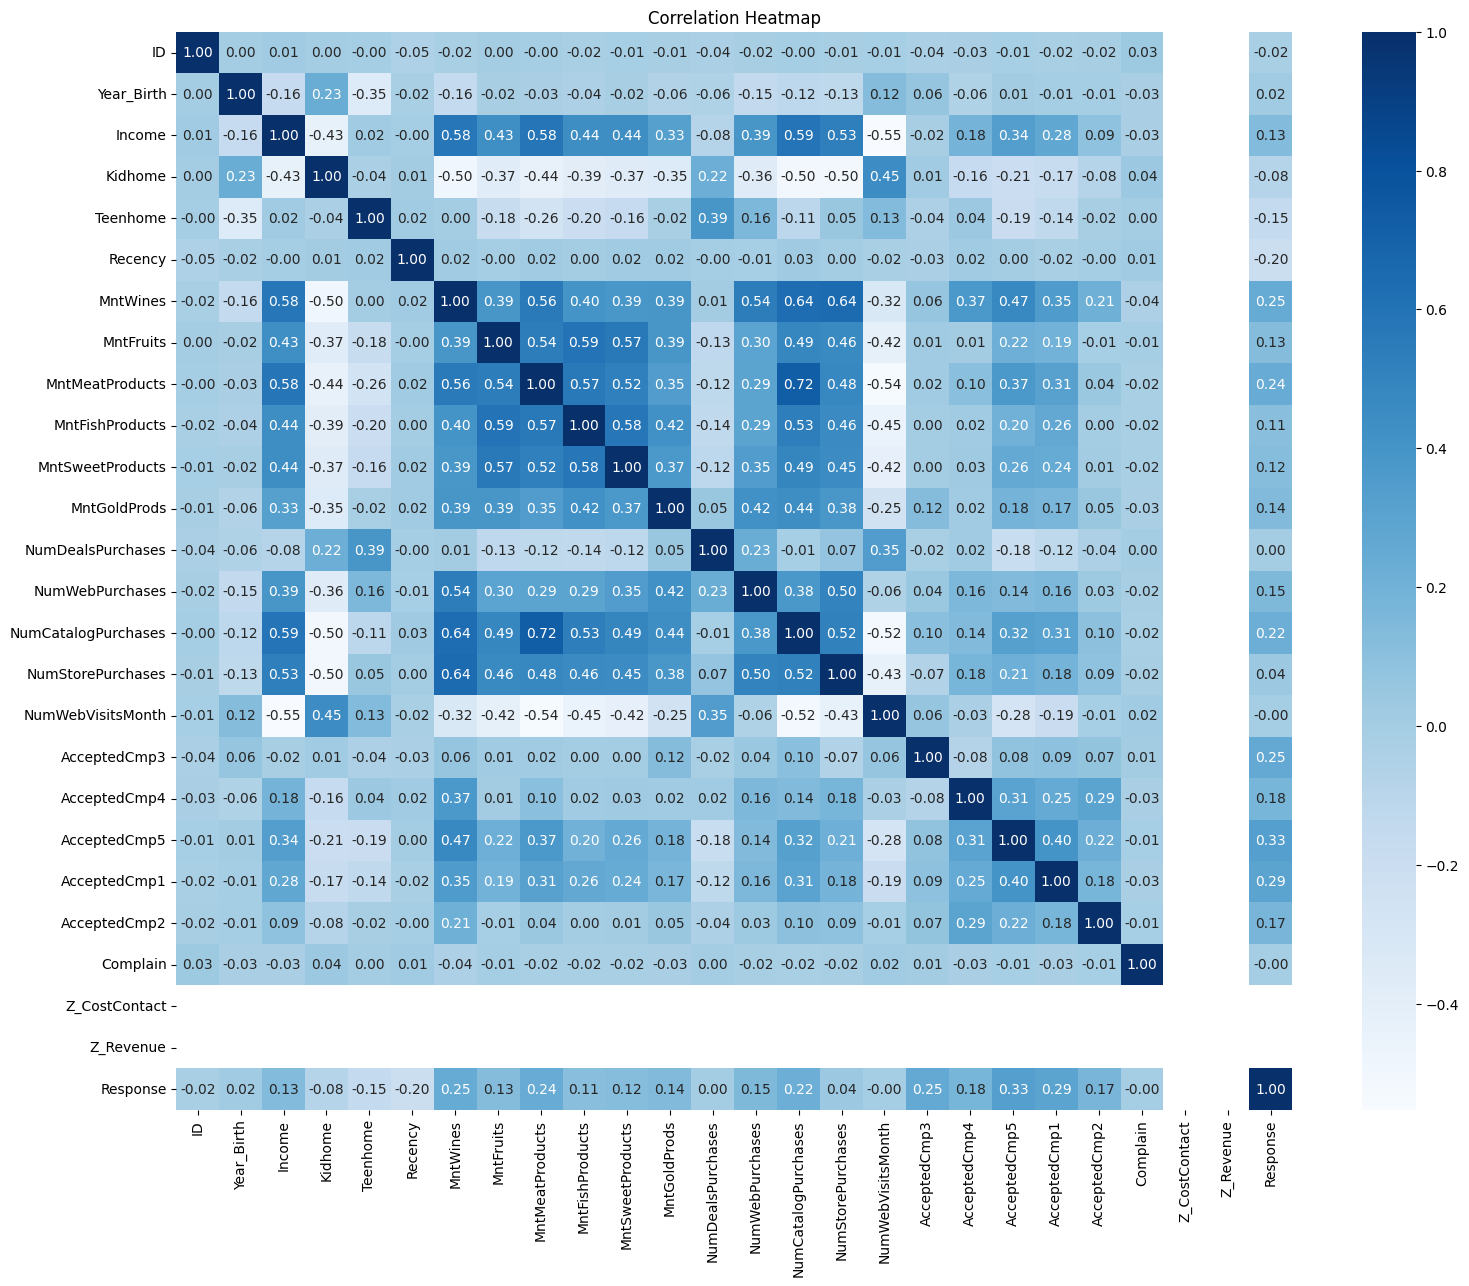

In [95]:
# Correlation heatmap
plt.figure(figsize=(18,14))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='Blues', annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### PART 2 - Data Cleaning

##### Data Cleaning

In [60]:
# Make a copy to preserve original data
df_clean = df.copy()

##### Drop Irrelevant Columns

In [61]:
# ID has no predictive value
df_clean.drop(columns=['ID'], inplace=True)

# Z_CostContact and Z_Revenue have constant values (no variance)
df_clean.drop(columns=['Z_CostContact', 'Z_Revenue'], inplace=True)

##### Fix Data Types

In [62]:
# Convert Dt_Customer to datetime
df_clean['Dt_Customer'] = pd.to_datetime(df_clean['Dt_Customer'])

# Create new feature: customer tenure (in days)
df_clean['Customer_Tenure'] = (df_clean['Dt_Customer'].max() - df_clean['Dt_Customer']).dt.days

# Drop original date column (not directly useful for model)
df_clean.drop(columns=['Dt_Customer'], inplace=True)

##### Handle Missing Values

In [63]:
# Fill the missing values in 'Income' column with median
df_clean['Income'] = df_clean['Income'].fillna(df_clean['Income'].median())

##### Handle Outliers

In [64]:
# Income has extreme outliers (max ~666k vs median ~51k)
Q1 = df_clean['Income'].quantile(0.25)
Q3 = df_clean['Income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [65]:
# Keep realistic values only (do not aggressively remove valid high-income customers)
df_clean = df_clean[(df_clean['Income'] >= lower_bound) & (df_clean['Income'] <= upper_bound)]

##### Handle Invalid Values

In [66]:
# Year_Birth has unrealistic values (e.g., 1893)
# Convert to Age instead

current_year = pd.Timestamp.today().year
df_clean['Age'] = current_year - df_clean['Year_Birth']

# Remove unrealistic ages (e.g., >100 years old)
df_clean = df_clean[df_clean['Age'] <= 100]

# Drop original Year_Birth
df_clean.drop(columns=['Year_Birth'], inplace=True)

##### Clean Categorical Variables

In [67]:
# Standardize text (lowercase)
df_clean['Education'] = df_clean['Education'].str.strip().str.lower()
df_clean['Marital_Status'] = df_clean['Marital_Status'].str.strip().str.lower()

In [68]:
# Fix inconsistent marital categories
df_clean['Marital_Status'] = df_clean['Marital_Status'].replace({
    'married': 'partner',
    'together': 'partner',
    'single': 'single',
    'divorced': 'single',
    'widow': 'single',
    'alone': 'single',
    'absurd': 'single',
    'yolo': 'single'
})

##### Feature Engineering

In [69]:
# Total children in household
df_clean['Children'] = df_clean['Kidhome'] + df_clean['Teenhome']

In [70]:
# Total spending across all categories
df_clean['Total_Spending'] = (
    df_clean['MntWines'] + df_clean['MntFruits'] + df_clean['MntMeatProducts'] +
    df_clean['MntFishProducts'] + df_clean['MntSweetProducts'] + df_clean['MntGoldProds']
)

In [71]:
# Total purchases
df_clean['Total_Purchases'] = (
    df_clean['NumWebPurchases'] + df_clean['NumCatalogPurchases'] + df_clean['NumStorePurchases']
)

##### Drop Redundant Features

In [72]:
# Kidhome & Teenhome replaced by Children
df_clean.drop(columns=['Kidhome', 'Teenhome'], inplace=True)

##### Encode Categorical Variables

In [73]:
df_clean = pd.get_dummies(df_clean, columns=['Education', 'Marital_Status'], drop_first=True)

##### Convert Boolean to Integer

In [74]:
# Convert boolean columns (True/False) to 1/0

bool_cols = df_clean.select_dtypes(include='bool').columns

for col in bool_cols:
    df_clean[col] = df_clean[col].astype(int)

# Verify conversion
df_clean.dtypes

Income                   float64
Recency                    int64
MntWines                   int64
MntFruits                  int64
MntMeatProducts            int64
MntFishProducts            int64
MntSweetProducts           int64
MntGoldProds               int64
NumDealsPurchases          int64
NumWebPurchases            int64
NumCatalogPurchases        int64
NumStorePurchases          int64
NumWebVisitsMonth          int64
AcceptedCmp3               int64
AcceptedCmp4               int64
AcceptedCmp5               int64
AcceptedCmp1               int64
AcceptedCmp2               int64
Complain                   int64
Response                   int64
Customer_Tenure            int64
Age                        int64
Children                   int64
Total_Spending             int64
Total_Purchases            int64
Education_basic            int64
Education_graduation       int64
Education_master           int64
Education_phd              int64
Marital_Status_single      int64
dtype: obj

##### Final Validation Check

In [75]:
# Final shape after cleaning
df_clean.shape

(2229, 30)

In [76]:
# Missing values after cleaning
df_clean.isnull().sum()

Income                   0
Recency                  0
MntWines                 0
MntFruits                0
MntMeatProducts          0
MntFishProducts          0
MntSweetProducts         0
MntGoldProds             0
NumDealsPurchases        0
NumWebPurchases          0
NumCatalogPurchases      0
NumStorePurchases        0
NumWebVisitsMonth        0
AcceptedCmp3             0
AcceptedCmp4             0
AcceptedCmp5             0
AcceptedCmp1             0
AcceptedCmp2             0
Complain                 0
Response                 0
Customer_Tenure          0
Age                      0
Children                 0
Total_Spending           0
Total_Purchases          0
Education_basic          0
Education_graduation     0
Education_master         0
Education_phd            0
Marital_Status_single    0
dtype: int64

In [77]:
# Data types after cleaning
df_clean.dtypes

Income                   float64
Recency                    int64
MntWines                   int64
MntFruits                  int64
MntMeatProducts            int64
MntFishProducts            int64
MntSweetProducts           int64
MntGoldProds               int64
NumDealsPurchases          int64
NumWebPurchases            int64
NumCatalogPurchases        int64
NumStorePurchases          int64
NumWebVisitsMonth          int64
AcceptedCmp3               int64
AcceptedCmp4               int64
AcceptedCmp5               int64
AcceptedCmp1               int64
AcceptedCmp2               int64
Complain                   int64
Response                   int64
Customer_Tenure            int64
Age                        int64
Children                   int64
Total_Spending             int64
Total_Purchases            int64
Education_basic            int64
Education_graduation       int64
Education_master           int64
Education_phd              int64
Marital_Status_single      int64
dtype: obj

In [78]:
# Preview cleaned data
df_clean.head()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Tenure,Age,Children,Total_Spending,Total_Purchases,Education_basic,Education_graduation,Education_master,Education_phd,Marital_Status_single
0,58138.0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,663,69,0,1617,22,0,1,0,0,1
1,46344.0,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,113,72,2,27,4,0,1,0,0,1
2,71613.0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,312,61,0,776,20,0,1,0,0,0
3,26646.0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,139,42,1,53,6,0,1,0,0,0
4,58293.0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,161,45,1,422,14,0,0,0,1,0


### PART 3 - Data Preprocessing (Model Preparation)
##### Feature and Target Separation

In [79]:
# Define target variable (what we want to predict)
y = df_clean['Response']

# Define features (all other variables)
X = df_clean.drop(columns=['Response'])

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (2229, 29)
Target vector shape: (2229,)


##### Train-Test Split

In [81]:
# Split data into training and testing sets
# 80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important due to imbalanced target
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1783, 29)
Testing set: (446, 29)


##### Feature Scaling

In [83]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Scaling completed.")

Scaling completed.


##### Check Class Imbalance

In [84]:
# Check distribution of target variable
print("Target distribution (train):")
print(y_train.value_counts(normalize=True))

print("\nTarget distribution (test):")
print(y_test.value_counts(normalize=True))

Target distribution (train):
Response
0    0.850252
1    0.149748
Name: proportion, dtype: float64

Target distribution (test):
Response
0    0.849776
1    0.150224
Name: proportion, dtype: float64


### PART 4 - Model Building & Evaluation
##### Train Logistic Regression Model

In [86]:
# Initialize Logistic Regression model
# class_weight='balanced' helps handle class imbalance (~85/15 split)
log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Train model on scaled training data
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


##### Predictions - Logistic Regression

In [87]:
# Predict on test data
y_pred_log = log_model.predict(X_test_scaled)

# Predicted probabilities (useful for ROC curve)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

##### Evaluate Logistic Regression

In [88]:
print("=== Logistic Regression Evaluation ===")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

=== Logistic Regression Evaluation ===
Accuracy: 0.8408071748878924
Precision: 0.4807692307692308
Recall: 0.746268656716418
F1 Score: 0.5847953216374269

Confusion Matrix:
[[325  54]
 [ 17  50]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90       379
           1       0.48      0.75      0.58        67

    accuracy                           0.84       446
   macro avg       0.72      0.80      0.74       446
weighted avg       0.88      0.84      0.85       446



##### Confusion Matrix Visualization

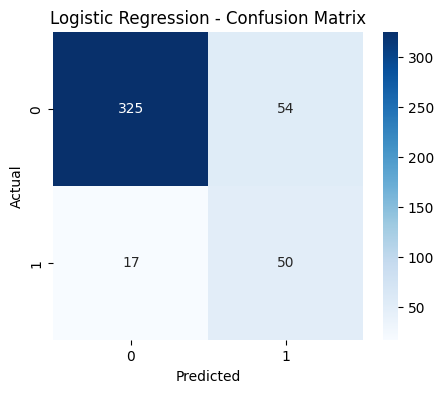

In [89]:
# Visualize confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), 
            annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##### Train Support Vector Machine (SVM)

In [90]:
# Initialize SVM model
# probability=True allows probability estimates for ROC curve
svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)

# Train model
svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


##### Predictions - SVM

In [91]:
# Predict on test data
y_pred_svm = svm_model.predict(X_test_scaled)

# Predicted probabilities
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

##### Evaluate SVM

In [92]:
print("=== SVM Evaluation ===")

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

=== SVM Evaluation ===
Accuracy: 0.8565022421524664
Precision: 0.5161290322580645
Recall: 0.7164179104477612
F1 Score: 0.6

Confusion Matrix:
[[334  45]
 [ 19  48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.88      0.91       379
           1       0.52      0.72      0.60        67

    accuracy                           0.86       446
   macro avg       0.73      0.80      0.76       446
weighted avg       0.88      0.86      0.87       446



##### Confusion Matrix Visualization (SVM)

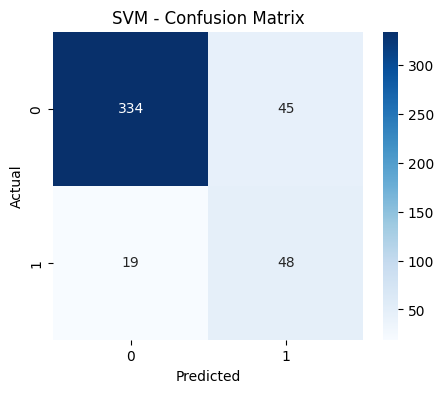

In [93]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), 
            annot=True, fmt='d', cmap='Blues')
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##### ROC Curve Comparison

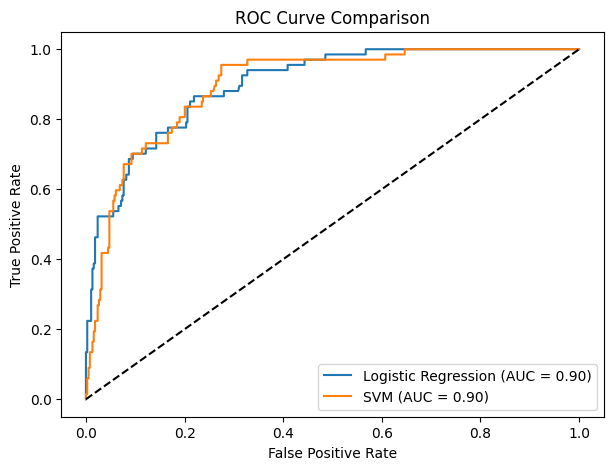

In [94]:
# Logistic Regression ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
roc_auc_log = auc(fpr_log, tpr_log)

# SVM ROC
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Plot ROC curves
plt.figure(figsize=(7,5))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_log:.2f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_svm:.2f})')
plt.plot([0,1], [0,1], 'k--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### PART 5 – Interpretation & Business Insights

---

### 1. Overall Model Performance

Both models perform well in distinguishing customers who will subscribe vs not subscribe:

* **Logistic Regression**

  * Accuracy: **84.1%**
  * Precision: **48.1%**
  * Recall: **74.6%**
  * F1 Score: **0.58**
  * AUC: **0.90**

* **SVM**

  * Accuracy: **85.7%**
  * Precision: **51.6%**
  * Recall: **71.6%**
  * F1 Score: **0.60**
  * AUC: **0.90**

**Interpretation:**

* Both models have **strong classification ability (AUC = 0.90)**.
* SVM performs slightly better overall (higher accuracy, precision, F1).
* Logistic Regression has slightly higher recall.

---

### 2. Class Imbalance Impact

* Dataset is **highly imbalanced (~85% No, 15% Yes)**.
* This explains:

  * High accuracy (easy to predict majority class)
  * Lower precision for class “Yes”

**Key Insight:**
Accuracy alone is misleading - **recall and precision are more important**.

---

### 3. Confusion Matrix Insights

#### Logistic Regression

* True Positives: **50**
* False Positives: **54**
* False Negatives: **17**

#### SVM

* True Positives: **48**
* False Positives: **45**
* False Negatives: **19**

**Interpretation:**

* Logistic Regression:

  * Captures **more actual subscribers** (higher recall)
  * But makes **more false alarms** (lower precision)
* SVM:

  * Slightly fewer false positives → **better precision**
  * Slightly more missed subscribers

---

### 4. Model Comparison (Business Perspective)

| Metric    | Logistic Regression | SVM      |
| --------- | ------------------- | -------- |
| Accuracy  | 0.84                | **0.86** |
| Precision | 0.48                | **0.52** |
| Recall    | **0.75**            | 0.72     |
| F1 Score  | 0.58                | **0.60** |
| AUC       | 0.90                | 0.90     |

---

### 5. Which Model Should Be Used?

Depends on business goal:

#### If the goal is:

* **Maximize subscriptions (don’t miss potential customers)**
  → Use **Logistic Regression** (higher recall)

* **Reduce marketing cost (avoid targeting wrong customers)**
  → Use **SVM** (higher precision)

**Recommended choice:**
SVM is slightly better overall due to balanced performance.

---

### 6. Business Insights

From the modeling and earlier EDA:

* Customers with **higher spending (Total_Spending)** are more likely to subscribe
* **Previous campaign acceptance (AcceptedCmp variables)** strongly influences response
* **Recency** negatively impacts response (recent customers less likely to respond)
* **Income** has a moderate positive relationship with subscription

---

### 7. Actionable Recommendations

* Target customers who:

  * Have **high total spending**
  * Previously accepted campaigns
  * Have moderate-to-high income

* Avoid:

  * Customers with **very recent interactions** (low response likelihood)

* Use model predictions to:

  * Prioritize **high-probability customers**
  * Optimize marketing budget

---

### 8. Final Conclusion

* Both models are effective, with **AUC = 0.90 indicating strong predictive power**
* **SVM is slightly better overall**, but Logistic Regression is better for recall-focused strategies
* The model can significantly improve **targeted marketing efficiency and ROI**